# 6차시 실습 — 실제 산업 이미지로 비전 품질검사 PoC 만들기

Kolektor Surface-Defect Dataset의 실제 산업 이미지 399장을 사용합니다.

```text
이미지·마스크 → 부품 그룹 분리 → 특징 추출 → 분류 모델
→ 운영 임계값 → 조명·초점·해상도 변화 → 품질 게이트 → 사람 검토
```

> 모델 출력은 불량 확정이 아니라 검토 후보입니다. 폐기·공정정지는 승인된 검사 절차를 따라야 합니다.

> 촬영 조건 변화는 교육용 픽셀 변환이며 실제 카메라 검증을 대신하지 않습니다.

## STEP 0. 패키지 준비

In [ ]:
# !pip -q install pandas numpy matplotlib pillow scikit-learn joblib

from pathlib import Path
import io, json, urllib.request, zipfile
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 30)
print("준비 완료")

준비 완료


## STEP 1. 공식 배포처에서 실제 데이터 받기

- 실제 통제된 산업 환경의 표면 이미지
- 399장, 정밀 마스크 399장
- CC BY-NC-SA 4.0, 비상업 교육·연구 조건 확인 필요

In [ ]:
DATASET_URL = "https://data.vicos.si/datasets/KSDD/KolektorSDD.zip"
ZIP_PATH = Path("/content/KolektorSDD.zip")
if not ZIP_PATH.exists():
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)

with zipfile.ZipFile(ZIP_PATH) as archive:
    image_names = sorted(
        name for name in archive.namelist()
        if name.lower().endswith(".jpg")
    )
    mask_names = sorted(
        name for name in archive.namelist()
        if name.lower().endswith(".bmp")
    )
print("원본 이미지:", len(image_names))
print("정밀 마스크:", len(mask_names))

원본 이미지: 399
정밀 마스크: 399


## STEP 2. 이미지와 같은 이름의 불량 마스크 읽기

In [ ]:
def read_pair(archive, image_name):
    mask_name = image_name[:-4] + "_label.bmp"
    with archive.open(image_name) as file:
        image = Image.open(io.BytesIO(file.read())).convert("L")
    with archive.open(mask_name) as file:
        mask = np.asarray(Image.open(io.BytesIO(file.read())).convert("L"))
    return image, mask

with zipfile.ZipFile(ZIP_PATH) as archive:
    for image_name in image_names:
        image, mask = read_pair(archive, image_name)
        if mask.max() > 0:
            example_name, example_image, example_mask = image_name, image, mask
            break
print(example_name, example_image.size)

kos01/Part5.jpg (500, 1270)


## STEP 3. 실제 불량 영역을 빨간색으로 확인

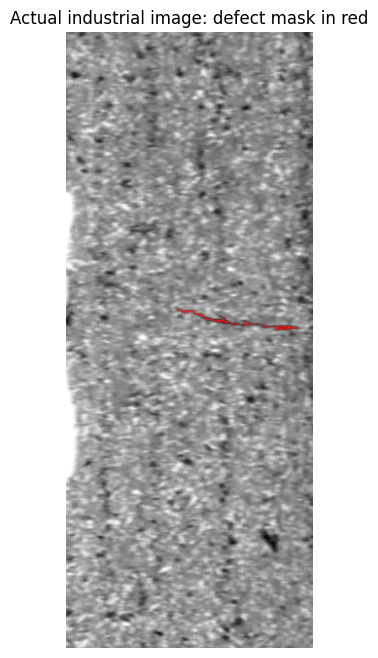

In [ ]:
display_image = example_image.resize((240, 600), Image.Resampling.BILINEAR)
display_mask = Image.fromarray(example_mask).resize((240, 600), Image.Resampling.NEAREST)
image_array = np.asarray(display_image)
mask_array = np.asarray(display_mask) > 0

plt.figure(figsize=(5, 8))
plt.imshow(image_array, cmap="gray")
overlay = np.zeros((*mask_array.shape, 4))
overlay[mask_array] = [1.0, 0.1, 0.1, 0.75]
plt.imshow(overlay)
plt.title("Actual industrial image: defect mask in red")
plt.axis("off")
plt.show()

### 출력 해석 1 — 작은 균열은 쉽게 사라진다

- 빨간 선은 사람이 만든 실제 불량 마스크입니다.
- 결함은 전체 이미지에 비해 매우 작아 과도하게 축소하면 픽셀이 사라집니다.
- 배경에도 어두운 무늬가 많으므로 단순 밝기 규칙만으로 구분하기 어렵습니다.
- 마스크는 평가 정답으로만 쓰며 모델 입력으로 주지 않습니다.
- 위치까지 출력하려면 이미지 분류가 아니라 탐지·분할 모델이 필요합니다.

## STEP 4. 이미지 카탈로그와 실제 라벨 만들기

In [ ]:
records = []
with zipfile.ZipFile(ZIP_PATH) as archive:
    for image_name in image_names:
        image, mask = read_pair(archive, image_name)
        label = int(mask.max() > 0)
        records.append({
            "image_name": image_name,
            "part_group": image_name.split("/")[0],
            "actual_label": label,
            "actual_class": "DEFECT" if label else "GOOD",
            "defect_pixels": int((mask > 0).sum()),
        })
metadata = pd.DataFrame(records)
metadata.head()

,image_name,part_group,actual_label,actual_class,defect_pixels
0,kos01/Part0.jpg,kos01,0,GOOD,0
1,kos01/Part1.jpg,kos01,0,GOOD,0
2,kos01/Part2.jpg,kos01,0,GOOD,0
3,kos01/Part3.jpg,kos01,0,GOOD,0
4,kos01/Part4.jpg,kos01,0,GOOD,0


In [ ]:
metadata.tail()

,image_name,part_group,actual_label,actual_class,defect_pixels
394,kos50/Part3.jpg,kos50,0,GOOD,0
395,kos50/Part4.jpg,kos50,1,DEFECT,4853
396,kos50/Part5.jpg,kos50,0,GOOD,0
397,kos50/Part6.jpg,kos50,0,GOOD,0
398,kos50/Part7.jpg,kos50,0,GOOD,0


In [ ]:
metadata.sample(20)

,image_name,part_group,actual_label,actual_class,defect_pixels
297,kos38/Part2.jpg,kos38,0,GOOD,0
330,kos42/Part3.jpg,kos42,1,DEFECT,2743
91,kos12/Part3.jpg,kos12,0,GOOD,0
270,kos34/Part7.jpg,kos34,0,GOOD,0
146,kos19/Part2.jpg,kos19,0,GOOD,0
341,kos43/Part6.jpg,kos43,0,GOOD,0
104,kos14/Part0.jpg,kos14,0,GOOD,0
339,kos43/Part4.jpg,kos43,0,GOOD,0
236,kos30/Part5.jpg,kos30,0,GOOD,0
214,kos27/Part7.jpg,kos27,0,GOOD,0


## STEP 5. 정상·불량 불균형 확인

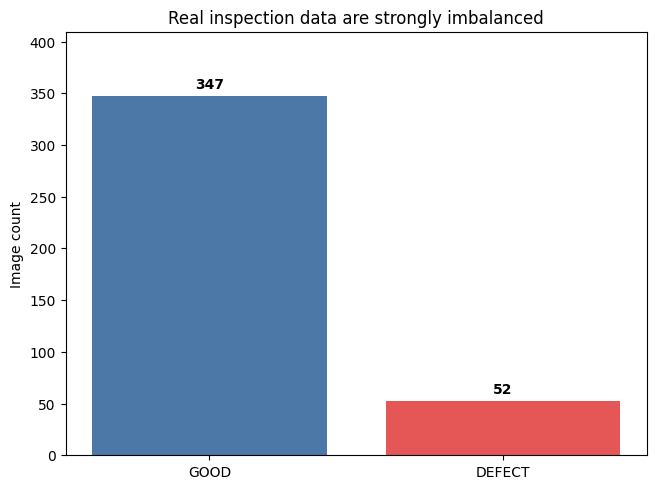

In [ ]:
counts = metadata["actual_class"].value_counts().reindex(["GOOD", "DEFECT"])
plt.figure(figsize=(7.5, 5.5))
bars = plt.bar(counts.index, counts.values, color=["#4C78A8", "#E45756"])
plt.ylabel("Image count")
plt.title("Real inspection data are strongly imbalanced")
for bar, value in zip(bars, counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, value+8, f"{int(value)}",
             ha="center", fontweight="bold")
plt.ylim(0, counts.max()*1.18)
plt.show()

### 출력 해석 2 — 높은 정확도도 불량을 놓칠 수 있다

- 정상 347장, 불량 52장으로 정상 비율이 약 87%입니다.
- 모두 정상이라고만 예측해도 정확도는 약 87%지만 불량 재현율은 0%입니다.
- 실제 생산에서 정상 이미지가 많은 것은 자연스러우므로 정확도만 보고하면 안 됩니다.
- 불량 재현율, 정밀도, 혼동표와 사람 검토량을 함께 봐야 합니다.

## STEP 6. 이미지 품질과 설명 가능한 특징 함수

밝기·대비·선명도와 방향별 경계 분포를 계산합니다. -> 전처리


In [ ]:
FEATURE_SIZE = (64, 160)

def quality_metrics(image):
    a = np.asarray(image.resize(FEATURE_SIZE), dtype=np.float32)
    gx = np.diff(a, axis=1, prepend=a[:, :1])
    gy = np.diff(a, axis=0, prepend=a[:1, :])
    lap = (-4*a + np.roll(a,1,0)+np.roll(a,-1,0)+np.roll(a,1,1)+np.roll(a,-1,1))
    return {"brightness":float(a.mean()), "contrast":float(a.std()),
            "sharpness":float(lap.var()), "mean_gradient":float(np.hypot(gx,gy).mean())}

def extract_features(image):
    a = np.asarray(image.resize(FEATURE_SIZE, Image.Resampling.BILINEAR), dtype=np.float32)/255
    gx = np.diff(a, axis=1, prepend=a[:, :1])
    gy = np.diff(a, axis=0, prepend=a[:1, :])
    mag = np.hypot(gx, gy)
    ori = (np.degrees(np.arctan2(gy, gx))+180)%180
    hog, bins = [], np.linspace(0, 180, 10)
    for row in range(0, 160, 8):
        for col in range(0, 64, 8):
            hist, _ = np.histogram(ori[row:row+8,col:col+8], bins=bins,
                                   weights=mag[row:row+8,col:col+8])
            hog.extend(hist/(hist.sum()+1e-6))
    intensity, _ = np.histogram(a, bins=16, range=(0,1), density=True)
    percentiles = np.percentile(a, [1,5,25,50,75,95,99])
    extra = [a.mean(), a.std(), mag.mean(), np.percentile(mag,90), np.percentile(mag,99)]
    return np.concatenate([hog, intensity, percentiles, extra])

## STEP 7. 특징 추출과 부품 그룹 분리

같은 `kosXX` 부품의 여러 이미지가 학습과 시험에 섞이지 않게 합니다.

In [ ]:
feature_rows, quality_rows = [], []
with zipfile.ZipFile(ZIP_PATH) as archive:
    for image_name in metadata["image_name"]:
        image, _ = read_pair(archive, image_name)
        feature_rows.append(extract_features(image))
        quality_rows.append(quality_metrics(image))
X = np.vstack(feature_rows)
for column in ["brightness", "contrast", "sharpness", "mean_gradient"]:
    metadata[column] = [row[column] for row in quality_rows]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_index, test_index = next(splitter.split(
    metadata, metadata["actual_label"], groups=metadata["part_group"]
))
train_metadata = metadata.iloc[train_index].copy()
test_metadata = metadata.iloc[test_index].copy()
print("학습", len(train_index), "장 /", train_metadata.part_group.nunique(), "개 부품")
print("시험", len(test_index), "장 /", test_metadata.part_group.nunique(), "개 부품")

학습 279 장 / 35 개 부품
시험 120 장 / 15 개 부품


## STEP 8. 내부 검증으로 불량 누락 우선 임계값 선택

시험 데이터는 임계값 선택에 사용하지 않습니다.

In [ ]:
def new_model():
    return make_pipeline(StandardScaler(), LogisticRegression(
        class_weight="balanced", max_iter=2500, random_state=42
    ))

inner_meta = metadata.iloc[train_index].reset_index(drop=True)
inner_split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=43)
inner_pos, val_pos = next(inner_split.split(
    inner_meta, inner_meta["actual_label"], groups=inner_meta["part_group"]
))
inner_idx, val_idx = train_index[inner_pos], train_index[val_pos]
threshold_model = new_model()
threshold_model.fit(X[inner_idx], metadata.iloc[inner_idx]["actual_label"])
val_y = metadata.iloc[val_idx]["actual_label"].to_numpy()
val_probability = threshold_model.predict_proba(X[val_idx])[:,1]

candidates = []
for threshold in np.linspace(0.01, 0.99, 99):
    p = (val_probability >= threshold).astype(int)
    candidates.append({
        "threshold":threshold,
        "recall":recall_score(val_y,p,zero_division=0),
        "precision":precision_score(val_y,p,zero_division=0),
        "review_rate":p.mean(),
    })
eligible = [row for row in candidates if row["recall"] >= 0.80]
selected = max(eligible, key=lambda row:(row["precision"],row["threshold"]))
OPERATING_THRESHOLD = selected["threshold"]
print(selected)

{'threshold': np.float64(0.01), 'recall': 0.8888888888888888, 'precision': 0.2857142857142857, 'review_rate': np.float64(0.3888888888888889)}


선택 결과는 약 `0.01`입니다. 매우 낮은 값은 모델 분리력이 약해 많은 정상 오경보를 허용해야 했다는 경고입니다.

## STEP 9. 전체 학습 데이터로 기준선 모델 학습

In [ ]:
model = new_model()
model.fit(X[train_index], metadata.iloc[train_index]["actual_label"])
limits = {
    "brightness_low": train_metadata["brightness"].quantile(0.01),
    "brightness_high": train_metadata["brightness"].quantile(0.99),
    "contrast_low": train_metadata["contrast"].quantile(0.01),
    "sharpness_low": train_metadata["sharpness"].quantile(0.01),
}
limits

{'brightness_low': np.float64(155.91516815185548),
 'brightness_high': np.float64(205.02719940185546),
 'contrast_low': np.float64(12.401019020080566),
 'sharpness_low': np.float64(731.5283142089844)}

## STEP 10. 촬영 조건과 품질 게이트 함수

In [ ]:
CONDITIONS = ["CONTROLLED","UNDEREXPOSED","OVEREXPOSED","BLURRED","LOW_RESOLUTION"]
LABELS = {"CONTROLLED":"Controlled","UNDEREXPOSED":"Underexposed",
          "OVEREXPOSED":"Overexposed","BLURRED":"Blurred","LOW_RESOLUTION":"Low resolution"}

def apply_condition(image, condition):
    if condition == "CONTROLLED": return image.copy()
    a = np.asarray(image, dtype=np.float32)
    if condition == "UNDEREXPOSED": return Image.fromarray(np.clip(a*.35,0,255).astype(np.uint8))
    if condition == "OVEREXPOSED": return Image.fromarray(np.clip(a*.35+170,0,255).astype(np.uint8))
    if condition == "BLURRED": return image.filter(ImageFilter.GaussianBlur(radius=4))
    if condition == "LOW_RESOLUTION":
        small = image.resize((image.width//8,image.height//8), Image.Resampling.BILINEAR)
        return small.resize(image.size, Image.Resampling.BILINEAR)

def quality_ok(q):
    return (limits["brightness_low"] <= q["brightness"] <= limits["brightness_high"]
            and q["contrast"] >= limits["contrast_low"]
            and q["sharpness"] >= limits["sharpness_low"])

## STEP 11. 같은 시험 이미지에 다섯 촬영 조건 적용

In [ ]:
rows = []
with zipfile.ZipFile(ZIP_PATH) as archive:
    for condition in CONDITIONS:
        for record in test_metadata.itertuples(index=False):
            image, _ = read_pair(archive, record.image_name)
            changed = apply_condition(image, condition)
            q = quality_metrics(changed)
            probability = model.predict_proba(extract_features(changed).reshape(1,-1))[0,1]
            default_prediction = int(probability >= .50)
            prediction = int(probability >= OPERATING_THRESHOLD)
            gate = quality_ok(q)
            route = ("RECAPTURE_OR_HUMAN_REVIEW" if not gate else
                     "DEFECT_CANDIDATE_REVIEW" if prediction else "POLICY_PASS")
            rows.append({"condition":condition,"condition_label":LABELS[condition],
                "image_name":record.image_name,"actual_label":record.actual_label,
                "defect_probability":probability,"default_prediction":default_prediction,
                "prediction":prediction,"quality_gate_pass":gate,"routing_status":route,**q})
predictions = pd.DataFrame(rows)

metric_rows = []
for condition, group in predictions.groupby("condition", sort=False):
    y = group["actual_label"]
    p, d = group["prediction"], group["default_prediction"]
    metric_rows.append({"condition":condition,"condition_label":LABELS[condition],
        "accuracy":accuracy_score(y,p),"precision_defect":precision_score(y,p,zero_division=0),
        "recall_defect":recall_score(y,p,zero_division=0),
        "default_recall_defect":recall_score(y,d,zero_division=0),
        "quality_reject_rate":1-group["quality_gate_pass"].mean()})
condition_metrics = pd.DataFrame(metric_rows)
condition_metrics

,condition,condition_label,accuracy,precision_defect,recall_defect,default_recall_defect,quality_reject_rate
0,CONTROLLED,Controlled,0.741667,0.285714,0.6250,0.1875,0.008333
1,UNDEREXPOSED,Underexposed,0.133333,0.133333,1.0000,1.0000,1.000000
2,OVEREXPOSED,Overexposed,0.833333,0.409091,0.5625,0.1250,1.000000
3,BLURRED,Blurred,0.783333,0.291667,0.4375,0.1250,0.991667
4,LOW_RESOLUTION,Low resolution,0.825000,0.368421,0.4375,0.1250,1.000000


## STEP 12. 임계값과 촬영 조건별 불량 재현율

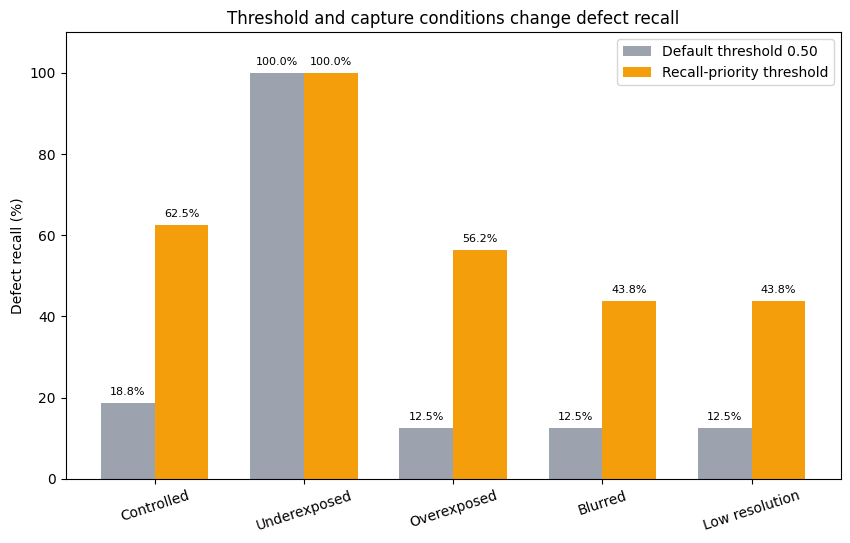

In [ ]:
x = np.arange(len(condition_metrics)); width=.36
default_values = condition_metrics["default_recall_defect"]*100
operating_values = condition_metrics["recall_defect"]*100
plt.figure(figsize=(10,5.8))
bars1=plt.bar(x-width/2,default_values,width,label="Default threshold 0.50",color="#9CA3AF")
bars2=plt.bar(x+width/2,operating_values,width,label="Recall-priority threshold",color="#F59E0B")
plt.xticks(x,condition_metrics["condition_label"],rotation=18)
plt.ylabel("Defect recall (%)")
plt.title("Threshold and capture conditions change defect recall")
plt.legend(); plt.ylim(0,110)
for bars,values in [(bars1,default_values),(bars2,operating_values)]:
    for bar,value in zip(bars,values):
        plt.text(bar.get_x()+bar.get_width()/2,value+2,f"{value:.1f}%",ha="center",fontsize=8)
plt.show()

### 출력 해석 3 — 100%도 의심해야 한다

- 통제 촬영에서 기본 임계값 재현율은 18.8%, 누락 우선 임계값은 62.5%입니다.
- 누락 우선 정책은 불량 16장 중 10장을 찾지만 정상 25장도 검토 대상으로 보냅니다.
- 저조도 재현율 100%는 좋은 결과가 아닙니다. 거의 모든 이미지를 불량으로 보아 정밀도와 정확도가 13.3%입니다.
- 과노출·흐림·저해상도에서는 통제 촬영보다 누락 우선 재현율도 낮아집니다.
- 이 기준선은 양산 준비가 되지 않았으며 촬영계·데이터·모델 개선이 필요합니다.

## STEP 13. 촬영 품질 게이트 반려율

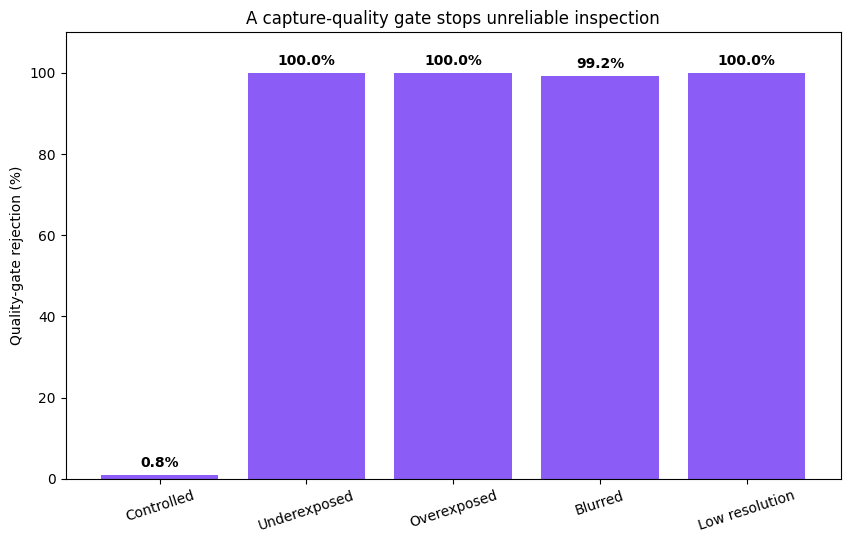

In [ ]:
values=condition_metrics["quality_reject_rate"]*100
plt.figure(figsize=(10,5.8))
bars=plt.bar(condition_metrics["condition_label"],values,color="#8B5CF6")
plt.ylabel("Quality-gate rejection (%)")
plt.title("A capture-quality gate stops unreliable inspection")
plt.xticks(rotation=18); plt.ylim(0,110)
for bar,value in zip(bars,values):
    plt.text(bar.get_x()+bar.get_width()/2,value+2,f"{value:.1f}%",ha="center",fontweight="bold")
plt.show()

### 출력 해석 4 — 판정하지 않는 것도 안전한 판정이다

- 통제 촬영 반려율은 0.8%입니다.
- 저조도·과노출·저해상도는 100%, 흐림은 99.2% 반려됩니다.
- 품질 게이트는 불량 모델이 아니라 믿기 어려운 입력을 재촬영·사람 검토로 보내는 장치입니다.
- 교육용 조건 변화가 강하므로 거의 모두 반려된 것이며 현장 기준은 실제 허용 범위 실험으로 승인해야 합니다.
- 반복 품질 실패는 카메라·렌즈·조명 점검 작업지시로 연결할 수 있습니다.

## STEP 14. 통제 촬영 혼동표와 PoC 상태 확인

In [ ]:
controlled=predictions[predictions["condition"]=="CONTROLLED"]
matrix=confusion_matrix(controlled["actual_label"],controlled["prediction"],labels=[0,1])
print(pd.DataFrame(matrix,index=["실제 정상","실제 불량"],columns=["예측 정상","불량 후보"]))
print("\n라우팅 상태")
print(controlled["routing_status"].value_counts())

       예측 정상  불량 후보
실제 정상     79     25
실제 불량      6     10

라우팅 상태
routing_status
POLICY_PASS                  84
DEFECT_CANDIDATE_REVIEW      35
RECAPTURE_OR_HUMAN_REVIEW     1
Name: count, dtype: int64


혼동표는 `[[79, 25], [6, 10]]`입니다. 불량 6장 누락과 정상 25장 추가 검토를 현장이 허용할 수 있는지 판단해야 합니다.

## STEP 15. PoC 산출물 저장

In [ ]:
OUTPUT_DIR=Path("/content/lesson06_outputs"); OUTPUT_DIR.mkdir(exist_ok=True)
metadata.to_csv(OUTPUT_DIR/"image_catalog.csv",index=False)
predictions.to_csv(OUTPUT_DIR/"condition_predictions.csv",index=False)
condition_metrics.to_csv(OUTPUT_DIR/"condition_metrics.csv",index=False)

# 모델뿐 아니라 Streamlit 추론에 필요한 임계값과 품질 기준도 함께 저장합니다.
model_bundle = {
    "model": model,  # StandardScaler와 LogisticRegression이 들어 있는 Pipeline
    "feature_size": FEATURE_SIZE,
    "operating_threshold": float(OPERATING_THRESHOLD),
    "quality_limits": {key: float(value) for key, value in limits.items()},
    "class_names": {0: "GOOD", 1: "DEFECT"},
    "feature_extractor": "lesson06_hog_intensity_v1",
    "dataset": "Kolektor Surface-Defect Dataset (KSDD)",
    "safety_note": "AI 출력은 불량 확정이 아니라 검토 후보입니다.",
}
MODEL_PATH = OUTPUT_DIR / "lesson06_vision_model.joblib"
joblib.dump(model_bundle, MODEL_PATH)

summary={"dataset":"KolektorSDD","images":399,"good":347,"defect":52,
         "train_images":len(train_index),"test_images":len(test_index),
         "operating_threshold":float(OPERATING_THRESHOLD),
         "controlled_confusion_matrix":matrix.tolist(),
         "saved_model":MODEL_PATH.name,
         "safety":"AI 출력은 검토 후보이며 폐기·공정정지는 승인 절차를 따름"}
with (OUTPUT_DIR/"summary.json").open("w",encoding="utf-8") as f:
    json.dump(summary,f,ensure_ascii=False,indent=2)
print(json.dumps(summary,ensure_ascii=False,indent=2))
print("저장 위치:",OUTPUT_DIR)
print("저장 모델:",MODEL_PATH)

{
  "dataset": "KolektorSDD",
  "images": 399,
  "good": 347,
  "defect": 52,
  "train_images": 279,
  "test_images": 120,
  "operating_threshold": 0.01,
  "controlled_confusion_matrix": [
    [
      79,
      25
    ],
    [
      6,
      10
    ]
  ],
  "saved_model": "lesson06_vision_model.joblib",
  "safety": "AI 출력은 검토 후보이며 폐기·공정정지는 승인 절차를 따름"
}
저장 위치: /content/lesson06_outputs
저장 모델: /content/lesson06_outputs/lesson06_vision_model.joblib


In [ ]:
import joblib
import zipfile
import io
from PIL import Image
import numpy as np
from pathlib import Path

# 필요한 경로를 재정의하고 모델 번들을 로드합니다.
# 이전 셀에서 정의된 MODEL_PATH를 사용합니다.
OUTPUT_DIR = Path("/content/lesson06_outputs")
MODEL_PATH = OUTPUT_DIR / "lesson06_vision_model.joblib"

# 모델 번들을 로드합니다.
model_bundle = joblib.load(MODEL_PATH)
model = model_bundle["model"]
OPERATING_THRESHOLD = model_bundle["operating_threshold"]
limits = model_bundle["quality_limits"]
FEATURE_SIZE = model_bundle["feature_size"]
CLASS_NAMES = model_bundle["class_names"]

# ZIP 파일에서 단일 이미지를 읽기 위한 헬퍼 함수입니다.
def read_single_image(archive, image_name):
    """ZIP 아카이브에서 단일 이미지를 읽습니다."""
    with archive.open(image_name) as file:
        image = Image.open(io.BytesIO(file.read())).convert("L")
    return image

# 예측할 샘플 이미지를 선택합니다.
# `test_metadata` 또는 `predictions` DataFrame에서 예시를 찾을 수 있습니다.
# 'kos04/Part3.jpg'는 제어된 조건에서 DEFECT (actual_label=1)였으며
# `predictions` DataFrame에서 'DEFECT_CANDIDATE_REVIEW'로 라우팅되었습니다.
example_image_name = "kos04/Part3.jpg"

print(f"이미지 '{example_image_name}'를 사용하여 예측을 수행합니다.")
print("다른 이미지를 테스트하려면 'example_image_name' 변수를 수정하거나 사용자 입력을 받도록 코드를 변경하세요.")

# ZIP 파일을 열고 선택한 이미지를 처리합니다.
with zipfile.ZipFile(ZIP_PATH) as archive:
    image_to_predict = read_single_image(archive, example_image_name)

    # 1. 품질 지표 계산
    q_metrics = quality_metrics(image_to_predict)
    quality_gate_passed = quality_ok(q_metrics)

    # 2. 특징 추출
    features_for_prediction = extract_features(image_to_predict).reshape(1, -1)

    # 3. 모델 예측
    defect_probability = model.predict_proba(features_for_prediction)[:, 1][0]
    prediction_label_idx = int(defect_probability >= OPERATING_THRESHOLD)
    classification_result = CLASS_NAMES[prediction_label_idx]

    # 4. 라우팅 상태 결정
    if not quality_gate_passed:
        routing_status = "RECAPTURE_OR_HUMAN_REVIEW (이미지 품질 미달)"
    elif classification_result == "DEFECT":
        routing_status = "DEFECT_CANDIDATE_REVIEW (불량 후보)"
    else:
        routing_status = "POLICY_PASS (정상)"

print(f"\n--- 예측 결과 ({example_image_name}) ---")
print(f"불량 확률: {defect_probability:.4f}")
print(f"예측: {classification_result}")
print(f"품질 게이트 통과: {quality_gate_passed}")
print(f"라우팅 상태: {routing_status}")

if not quality_gate_passed:
    print("\n[안내] 이미지 품질이 기준 미달입니다. 재촬영 또는 수동 검토가 필요합니다.")
elif classification_result == "DEFECT":
    print("\n[안내] 이 이미지는 불량 후보로 분류되었습니다. 추가 검토가 필요합니다.")
else:
    print("\n[안내] 이 이미지는 정상으로 분류되었습니다.")

이미지 'kos04/Part3.jpg'를 사용하여 예측을 수행합니다.
다른 이미지를 테스트하려면 'example_image_name' 변수를 수정하거나 사용자 입력을 받도록 코드를 변경하세요.

--- 예측 결과 (kos04/Part3.jpg) ---
불량 확률: 0.0003
예측: GOOD
품질 게이트 통과: True
라우팅 상태: POLICY_PASS (정상)

[안내] 이 이미지는 정상으로 분류되었습니다.


## STEP 16. 단일 이미지 대화형 판별

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# metadata DataFrame에서 이미지 이름 목록을 가져옵니다.
image_names_list = metadata["image_name"].tolist()

# 드롭다운 위젯 생성
image_selector_widget = widgets.Dropdown(
    options=image_names_list,
    value=image_names_list[0],  # 기본값 설정
    description='이미지 선택:',
    disabled=False,
)

display(image_selector_widget)

print("드롭다운에서 이미지를 선택한 후 다음 셀을 실행하세요.")

Dropdown(description='이미지 선택:', options=('kos01/Part0.jpg', 'kos01/Part1.jpg', 'kos01/Part2.jpg', 'kos01/Part3…

드롭다운에서 이미지를 선택한 후 다음 셀을 실행하세요.


In [ ]:
# 드롭다운에서 선택된 이미지 이름을 가져옵니다.
selected_image_name = image_selector_widget.value

print(f"선택된 이미지 '{selected_image_name}'를 사용하여 예측을 수행합니다.")

# ZIP 파일을 열고 선택한 이미지를 처리합니다.
with zipfile.ZipFile(ZIP_PATH) as archive:
    image_to_predict = read_single_image(archive, selected_image_name)

    # 1. 품질 지표 계산
    q_metrics = quality_metrics(image_to_predict)
    quality_gate_passed = quality_ok(q_metrics)

    # 2. 특징 추출
    features_for_prediction = extract_features(image_to_predict).reshape(1, -1)

    # 3. 모델 예측
    defect_probability = model.predict_proba(features_for_prediction)[:, 1][0]
    prediction_label_idx = int(defect_probability >= OPERATING_THRESHOLD)
    classification_result = CLASS_NAMES[prediction_label_idx]

    # 4. 라우팅 상태 결정
    if not quality_gate_passed:
        routing_status = "RECAPTURE_OR_HUMAN_REVIEW (이미지 품질 미달)"
    elif classification_result == "DEFECT":
        routing_status = "DEFECT_CANDIDATE_REVIEW (불량 후보)"
    else:
        routing_status = "POLICY_PASS (정상)"

print(f"\n--- 예측 결과 ({selected_image_name}) ---")
print(f"불량 확률: {defect_probability:.4f}")
print(f"예측: {classification_result}")
print(f"품질 게이트 통과: {quality_gate_passed}")
print(f"라우팅 상태: {routing_status}")

if not quality_gate_passed:
    print("\n[안내] 이미지 품질이 기준 미달입니다. 재촬영 또는 수동 검토가 필요합니다.")
elif classification_result == "DEFECT":
    print("\n[안내] 이 이미지는 불량 후보로 분류되었습니다. 추가 검토가 필요합니다.")
else:
    print("\n[안내] 이 이미지는 정상으로 분류되었습니다.")

선택된 이미지 'kos02/Part5.jpg'를 사용하여 예측을 수행합니다.

--- 예측 결과 (kos02/Part5.jpg) ---
불량 확률: 0.0019
예측: GOOD
품질 게이트 통과: True
라우팅 상태: POLICY_PASS (정상)

[안내] 이 이미지는 정상으로 분류되었습니다.


## 마무리

```text
좋은 촬영 → 품질 게이트 → AI 불량 후보 → 사람 검토 → 피드백
```

이 기준선은 양산 모델이 아닙니다. 낮은 성능을 통해 다음 개선 항목을 찾는 것이 PoC의 역할입니다.

- 더 많은 불량·정상 변동 수집
- 실제 조명·초점·위치 변화 시험
- 결함 패치와 전이학습 CNN 비교
- 탐지·분할 모델로 위치 평가
- 검사 시간·재촬영률·사람 검토량 측정

> 비전검사의 첫 번째 모델은 AI가 아니라 안정된 빛입니다.

In [ ]:
#코랩환경에서 로컬 스트립릿으로 모델을 서비스 테스트

In [ ]:
# === 1. 필요한 패키지 및 프로그램 다운로드 ===
!pip install -q streamlit
!wget -q -O cloudflared-linux-amd64 https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 85.6 MB/s eta 0:00:00


In [49]:
# 2. APP.PY 파일 만들기
%%writefile app.py
import streamlit as st

st.title("Hello Streamlit-er 👋")
st.markdown(
    """
    This is a playground for you to try Streamlit and have fun.

    **There's :rainbow[so much] you can build!**

    We prepared a few examples for you to get started. Just
    click on the buttons above and discover what you can do
    with Streamlit.
    """
)

if st.button("Send balloons!"):
    st.balloons()


Overwriting app.py


In [50]:
# === 3. 프로세스 백그라운드 실행 및 터널링 ===
import time
import os

# 기존 실행 중인 앱과 터널이 있다면 종료 (셀 재실행 시 포트 충돌 방지)
os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")

print("✨ 스트림릿 앱을 백그라운드에서 시작합니다...")
os.system("nohup streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &")

print("🌐 Cloudflare 서버망에 터널을 뚫는 중입니다... (약 5~7초 소요)")
os.system("nohup ./cloudflared-linux-amd64 tunnel --url http://localhost:8501 > tunnel.log 2>&1 &")

# 링크가 생성될 때까지 안전하게 대기
time.sleep(7)

✨ 스트림릿 앱을 백그라운드에서 시작합니다...
🌐 Cloudflare 서버망에 터널을 뚫는 중입니다... (약 5~7초 소요)


In [52]:
# === 4. 생성된 접속 링크 출력 ===
print("\n👇 아래 링크를 클릭하여 앱에 접속하세요! 👇")
!grep -o 'https://.*\.trycloudflare.com' tunnel.log


👇 아래 링크를 클릭하여 앱에 접속하세요! 👇
grep: tunnel.log: binary file matches


In [54]:
print("\n👇 아래 링크를 클릭하여 앱에 접속하세요! 👇")
!grep -oa 'https://.*\.trycloudflare.com' tunnel.log


👇 아래 링크를 클릭하여 앱에 접속하세요! 👇
https://cave-accountability-state-counter.trycloudflare.com
